# 1. Data
CIFAR10 is a subset of the 80 million tiny images dataset. They were collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. The dataset is available at CIFAR-10 and CIFAR-100 datasets (toronto.edu) and can also be loaded directly from TensorFlow using tf.keras.datasets.cifar10.load_data.

**Problem Statement:**
Image classification is an important part of computer vision systems. Equipped with a digital camera and a single board computer (such as a Raspberry Pi), smart technology can capture an image, determine what is in the image using a classification model, and then take an action based on that information. As a warmup exercise to develop such technology, consider that you are tasked to classify images from the CIFAR10 dataset. You are to build your own CNN model for this, both from scratch and from an existing model via transfer learning and fine tuning.
## 1.1 Load Data
Load CIFAR10 dataset into training and testing, features and labels numpy arrays using cifar10.load_data. Using markdown, list the 10 classes. 

In [22]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
(features_train, label_train), (features_test, label_test) = cifar10.load_data()

In [3]:
# Printing the unique labels in the training set
set(label_train.flatten())

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

### Classes obtained
We obtained the 10 classes to be the integer numbers from 0 to 9 (a total of 10 classes).

## 1.2 Bar Plot Checking for Classes Distribution
Create a bar plot using seaborn.barplot of the number of elements in each category of the entire dataset. Use markdown to comment on how well balanced the dataset is.

Text(0.5, 1.0, 'Distribution of CIFAR-10 Classes')

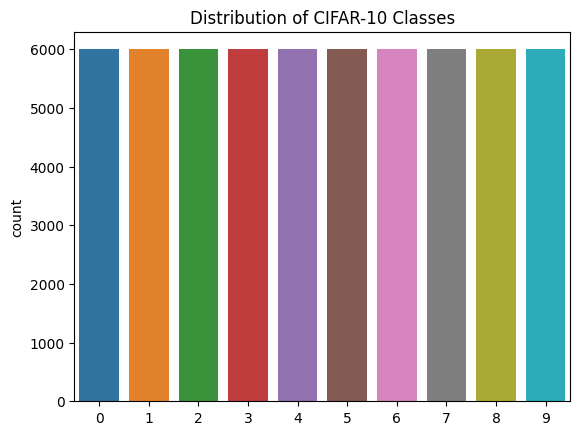

In [4]:
# Bar plot goes here
entire_dataset = list(label_train.flatten()) + list(label_test.flatten())
sns.countplot(x=entire_dataset)
plt.title('Distribution of CIFAR-10 Classes')

The dataset is perfectly balanced. Each one of the classes has exactly 6000 instances on it for a total of 60000 instances.

## 1.3 Splitting the dataset
Use sklearn.model_selection.train_test_split to split the test set into test and validation sets choosing appropriate proportions. 

In [5]:
label_train = label_train.flatten()
label_test = label_test.flatten()

features_val, features_test, label_val, label_test = train_test_split(features_test,
                                                                    label_test,
                                                                    test_size=0.5,
                                                                    random_state=42)

print(f"Training set shape: {features_train.shape}, {label_train.shape}")
print(f"Validation set shape: {features_val.shape}, {label_val.shape}")
print(f"Test set shape: {features_test.shape}, {label_test.shape}")

Training set shape: (50000, 32, 32, 3), (50000,)
Validation set shape: (5000, 32, 32, 3), (5000,)
Test set shape: (5000, 32, 32, 3), (5000,)


## 1.4 Data Generators
Create train, test, and validation data generators using tensorflow.keras.preprocessing.image.ImageDataGenerator; each should scale the data by dividing by 255, and the training generator should also use data augmentation. 

In [6]:
train_img_gen = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    rotation_range=20,          # random rotations (degrees)
    zoom_range=0.2,             # random zoom in/out
    shear_range=0.15,           # shear transformations
    brightness_range=[0.7, 1.3],# random brightness adjustments
    fill_mode='nearest',        # how to fill missing pixels after transforms
    channel_shift_range=20.0,   # random channel intensity shifts
    vertical_flip=False,
)
val_img_gen = ImageDataGenerator(rescale=1./255)
test_img_gen = ImageDataGenerator(rescale=1./255)

batch_size= 16
img_height = 32
img_width = 32

Running the flow functions on the CIFAR10 data

In [7]:
train_data_gen = train_img_gen.flow(features_train, label_train, batch_size=batch_size)
val_data_gen = val_img_gen.flow(features_val, label_val, batch_size=batch_size)
test_data_gen = test_img_gen.flow(features_test, label_test, batch_size=batch_size)

# 2. Modeling


## 2.1 CNN construction
Use tf.keras.Sequential to create a convolutional neural network. Use at least two convolution layers and at least two pooling layers. Choose an activation function for each layer, and make sure the input and output dimensions are appropriate for the data. Print a summary of the model using tf.summary.

In [8]:
np.random.seed(8)
tf.random.set_seed(8)

model = tf.keras.Sequential([
    layers.Conv2D(64, 3, activation='relu', input_shape=(img_height, img_width ,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 64)        1792      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 64)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 128)        0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 4608)              0         
                                                                 
 dense (Dense)               (None, 128)               5

## 2.2 Model Compiling
Compile the model with a choice of optimizer, sparse_categorical_crossentropy for the loss function, and set the metrics argument equal to ['accuracy'].

In [9]:
optimizer = tf.keras.optimizers.Adam(0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

## 2.3 Model Training
Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures other hyperparameters to improve upon the results.

In [10]:
model.fit(
    train_data_gen,
    steps_per_epoch=len(features_train) // batch_size,
    epochs=10,
    validation_data=val_data_gen,
    validation_steps=len(features_val) // batch_size
)

Epoch 1/10
3125/3125 [==============================] - 137s 43ms/step - loss: 1.4884 - accuracy: 0.4619 - val_loss: 1.1575 - val_accuracy: 0.5871
Epoch 2/10
3125/3125 [==============================] - 132s 42ms/step - loss: 1.1778 - accuracy: 0.5833 - val_loss: 1.0200 - val_accuracy: 0.6376
Epoch 3/10
3125/3125 [==============================] - 103s 33ms/step - loss: 1.0800 - accuracy: 0.6180 - val_loss: 1.0101 - val_accuracy: 0.6442
Epoch 4/10
3125/3125 [==============================] - 122s 39ms/step - loss: 1.0195 - accuracy: 0.6429 - val_loss: 1.0290 - val_accuracy: 0.6396
Epoch 5/10
3125/3125 [==============================] - 131s 42ms/step - loss: 0.9745 - accuracy: 0.6573 - val_loss: 0.9074 - val_accuracy: 0.6871
Epoch 6/10
3125/3125 [==============================] - 130s 41ms/step - loss: 0.9390 - accuracy: 0.6717 - val_loss: 0.9086 - val_accuracy: 0.6817
Epoch 7/10
3125/3125 [==============================] - 126s 40ms/step - loss: 0.9078 - accuracy: 0.6838 - val_loss: 0

## 2.4 Loading an Existant Model
Start a new model by loading one of the models from tensorflow.keras.applications along with the pretrained weights; don't include the top layer. Check if your model comes with preprocess_input function and be sure to use that properly with your data before training. Describe the model you chose using markdown and explain why you think it will work well for this use case.

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

np.random.seed(8)
tf.random.set_seed(8)

# Upscale CIFAR-10 images to a larger size (better for pretrained convnets)
img_height = 96
img_width = 96
batch_size = 64

# Resize numpy arrays (tf.image.resize returns float32) to match input shape
features_train_resized = tf.image.resize(features_train, [img_height, img_width]).numpy()
features_val_resized = tf.image.resize(features_val, [img_height, img_width]).numpy()
features_test_resized = tf.image.resize(features_test, [img_height, img_width]).numpy()

# Stronger augmentation and correct preprocessing for MobileNetV2 (maps to [-1,1])
train_img_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
                                   shear_range=0.15, zoom_range=0.15, horizontal_flip=True, fill_mode='nearest')
val_img_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_img_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create generators from resized numpy arrays
train_data_gen = train_img_gen.flow(features_train_resized, label_train, batch_size=batch_size)
val_data_gen = val_img_gen.flow(features_val_resized, label_val, batch_size=batch_size)
test_data_gen = test_img_gen.flow(features_test_resized, label_test, batch_size=batch_size)

### Explanation on preprocessing

In [12]:
base_model = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
# Freeze all base layers initially
base_model.trainable = False

9406464/9406464 [==============================] - 0s 0us/step


## 2.5 Adding top layers
Add on a new top layer with appropriate hyperparameter choices. Choose a number of layers to freeze. Print a summary of the model.

In [13]:
# Create new model with custom top layers
inputs = layers.Input(shape=(img_height, img_width, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)
transfer_model = models.Model(inputs, outputs)

## 2.6 Compiling the model
Compile the model with a choice of optimizer and loss function, and the set the metrics argument equal to ['accuracy'].

In [14]:

transfer_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()

Model: "model"


_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         


                                                                 
 mobilenetv2_1.00_96 (Functi  (None, 3, 3, 1280)       2257984   
 onal)                                                           
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               327936    
                                                                 
 batch_normalization_1 (Batc  (None, 256)              1024      
 hNormaliz

## 2.7 Train the model
Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures, different numbers of frozen layers, and other hyperparameters to improve upon the results.

In [15]:
history_head = transfer_model.fit(
    train_data_gen,
    epochs=30,
    steps_per_epoch=20,
    validation_data=val_data_gen,
    validation_steps=10
)


Epoch 1/30
20/20 [==============================] - 27s 1s/step - loss: 1.8701 - accuracy: 0.4219 - val_loss: 0.9452 - val_accuracy: 0.6984
Epoch 2/30
20/20 [==============================] - 10s 471ms/step - loss: 1.1134 - accuracy: 0.6438 - val_loss: 0.7344 - val_accuracy: 0.7453
Epoch 3/30
20/20 [==============================] - 9s 454ms/step - loss: 1.0505 - accuracy: 0.6781 - val_loss: 0.7088 - val_accuracy: 0.7750
Epoch 4/30
20/20 [==============================] - 9s 451ms/step - loss: 0.9739 - accuracy: 0.6914 - val_loss: 0.6927 - val_accuracy: 0.7766
Epoch 5/30
20/20 [==============================] - 10s 482ms/step - loss: 0.9179 - accuracy: 0.7109 - val_loss: 0.6029 - val_accuracy: 0.8016
Epoch 6/30
20/20 [==============================] - 9s 432ms/step - loss: 0.9066 - accuracy: 0.7078 - val_loss: 0.5664 - val_accuracy: 0.8125
Epoch 7/30
20/20 [==============================] - 24s 1s/step - loss: 0.8201 - accuracy: 0.7359 - val_loss: 0.5917 - val_accuracy: 0.7969
Epoch 8/

### Explanation of Fine Tuning
-
-
-

In [16]:
# Phase 2: fine-tune — unfreeze top layers of the base model and train with a low LR
base_model.trainable = True
# Freeze most layers, only leave the top block(s) trainable to avoid overfitting quickly
for layer in base_model.layers[:-40]:
    layer.trainable = False

transfer_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

history_fine = transfer_model.fit(
    train_data_gen,
    epochs=20,
    steps_per_epoch=20,
    validation_data=val_data_gen,
    validation_steps=10
)

Epoch 1/20
20/20 [==============================] - 26s 1s/step - loss: 0.6451 - accuracy: 0.7828 - val_loss: 0.4991 - val_accuracy: 0.8453
Epoch 2/20
20/20 [==============================] - 10s 477ms/step - loss: 0.6710 - accuracy: 0.7711 - val_loss: 0.4487 - val_accuracy: 0.8516
Epoch 3/20
20/20 [==============================] - 9s 462ms/step - loss: 0.6444 - accuracy: 0.7641 - val_loss: 0.5056 - val_accuracy: 0.8375
Epoch 4/20
20/20 [==============================] - 8s 416ms/step - loss: 0.6593 - accuracy: 0.7852 - val_loss: 0.5014 - val_accuracy: 0.8406
Epoch 5/20
20/20 [==============================] - 9s 431ms/step - loss: 0.6549 - accuracy: 0.7727 - val_loss: 0.4353 - val_accuracy: 0.8594
Epoch 6/20
20/20 [==============================] - 9s 446ms/step - loss: 0.6148 - accuracy: 0.7789 - val_loss: 0.4670 - val_accuracy: 0.8359
Epoch 7/20
20/20 [==============================] - 9s 479ms/step - loss: 0.6263 - accuracy: 0.7836 - val_loss: 0.4508 - val_accuracy: 0.8484
Epoch 8

# 3. Conclusion
## 3.a Training and Validation Accuracies
Find the training and validation accuracies, and validation confusion matrix for both the custom CNN and transfer learning models. Present the results for both neatly. Use markdown to compare them and select the best model.

### Base model CNN Analysis

In [25]:
final_train_acc_base = 0.7059
final_val_acc_base = 0.7133

print(f"Final Training Accuracy:   {final_train_acc_base:.4f}")
print(f"Final Validation Accuracy: {final_val_acc_base:.4f}")

Final Training Accuracy:   0.7059
Final Validation Accuracy: 0.7133


<Figure size 1000x800 with 0 Axes>

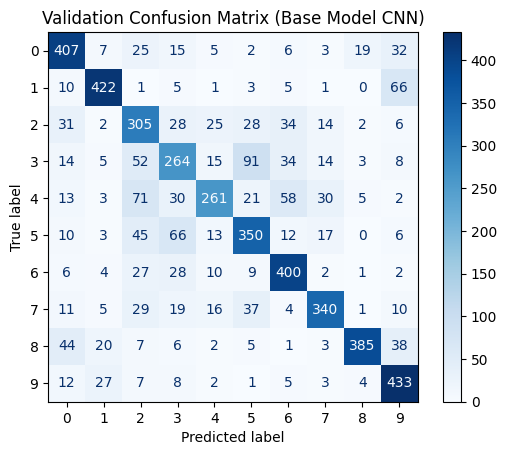

In [29]:
y_true_base = label_val
y_prob_base = model.predict(features_val.astype("float32") / 255.0, batch_size=batch_size, verbose=0)
y_pred_base = np.argmax(y_prob_base, axis=1)

cm = confusion_matrix(y_true_base, y_pred_base)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Validation Confusion Matrix (Base Model CNN)")
plt.show()

### Custom CNN Analysis

In [20]:
final_train_acc = history_fine.history["accuracy"][-1]
final_val_acc = history_fine.history["val_accuracy"][-1]

print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

Final Training Accuracy:   0.7891
Final Validation Accuracy: 0.8531


<Figure size 1000x800 with 0 Axes>

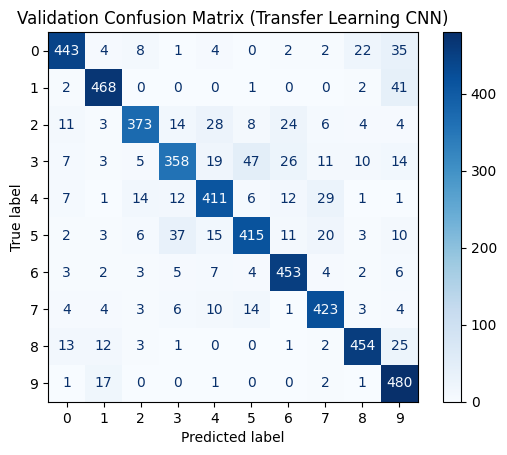

In [34]:

y_true = label_val
x_val = preprocess_input(features_val_resized.astype("float32"))
y_prob = transfer_model.predict(x_val, batch_size=batch_size, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Validation Confusion Matrix (Transfer Learning CNN)")
plt.show()

### Comparision and Model Selection

## 3.b Testing Accuracy
Find the testing accuracy and confusion matrix of only the best model.

## 3.c Prediction With External Images
Use the model to make predictions on at least three other images from one of the 10 classes

## 3.d Model Performance Conclusions
Use markdown to comment on how well the model works to make predictions for this use case.